In [22]:
import torch

import numpy as np
import matplotlib.pyplot as plt
import site
import pandas as pd

from pycamcoil.camcoil_engine import CamCoil

import MDAnalysis as MDA

from openmmnapshift.utils import RESIDUE_TYPES, ATOM_TYPES, CHI1_ATOMS, CHI2_ATOMS, read_chemical_shifts

BLOSUM = {
    "ALA": (+4, -1, -2, -2, +0, +0, -1, -1, +0, -2, -1, -1, -1, -1, -2, -1, -1, +1, +0, -3, -2, +0),
    "ARG": (-1, +5, +0, -2, -3, -3, +1, +0, -2, +0, -3, -2, +2, -1, -3, -2, -2, -1, -1, -3, -2, -3),
    "ASN": (-2, +0, +6, +1, -3, -3, +0, +0, +0, +1, -3, -3, +0, -2, -3, -2, -2, +1, +0, -4, -2, -3),
    "ASP": (-2, -2, +1, +6, -3, -3, +0, +2, -1, -1, -3, -4, -1, -3, -3, -1, -1, +0, -1, -4, -3, -3),
    "CYO": (+0, -3, -3, -3, +9, +8, -3, -4, -3, -3, -1, -1, -3, -1, -2, -3, -3, -1, -1, -2, -2, -1),
    "CYS": (+0, -3, -3, -3, +8, +9, -3, -4, -3, -3, -1, -1, -3, -1, -2, -3, -3, -1, -1, -2, -2, -1),
    "GLN": (-1, +1, +0, +0, -3, -3, +5, +2, -2, +0, -3, -2, +1, +0, -3, -1, -1, +0, -1, -2, -1, -2),
    "GLU": (-1, +0, +0, +2, -4, -4, +2, +5, -2, +0, -3, -3, +1, -2, -3, -1, -1, +0, -1, -3, -2, -2),
    "GLY": (+0, -2, +0, -1, -3, -3, -2, -2, +6, -2, -4, -4, -2, -3, -3, -2, -2, +0, -2, -2, -3, -3),
    "HIS": (-2, +0, +1, -1, -3, -3, +0, +0, -2, +8, -3, -3, -1, -2, -1, -2, -2, -1, -2, -2, +2, -3),
    "ILE": (-1, -3, -3, -3, -1, -1, -3, -3, -4, -3, +4, +2, -3, +1, +0, -3, -3, -2, -1, -3, -1, +3),
    "LEU": (-1, -2, -3, -4, -1, -1, -2, -3, -4, -3, +2, +4, -2, +2, +0, -3, -3, -2, -1, -2, -1, +1),
    "LYS": (-1, +2, +0, -1, -3, -3, +1, +1, -2, -1, -3, -2, +5, -1, -3, -1, -1, +0, -1, -3, -2, -2),
    "MET": (-1, -1, -2, -3, -1, -1, +0, -2, -3, -2, +1, +2, -1, +5, +0, -2, -2, -1, -1, -1, -1, +1),
    "PHE": (-2, -3, -3, -3, -2, -2, -3, -3, -3, -1, +0, +0, -3, +0, +6, -4, -4, -2, -2, +1, +3, -1),
    "PRC": (-1, -2, -2, -1, -3, -3, -1, -1, -2, -2, -3, -3, -1, -2, -4, +7, +6, -1, -1, -4, -3, -2),
    "PRO": (-1, -2, -2, -1, -3, -3, -1, -1, -2, -2, -3, -3, -1, -2, -4, +6, +7, -1, -1, -4, -3, -2),
    "SER": (+1, -1, +1, +0, -1, -1, +0, +0, +0, -1, -2, -2, +0, -1, -2, -1, -1, +4, +1, -3, -2, -2),
    "THR": (+0, -1, +0, -1, -1, -1, -1, -1, -2, -2, -1, -1, -1, -1, -2, -1, -1, +1, +5, -2, -2, +0),
    "TRP": (-3, -3, -4, -4, -2, -2, -2, -3, -2, -2, -3, -2, -3, -1, +1, -4, -4, -3, -2, 11, +2, -3),
    "TYR": (-2, -2, -2, -3, -2, -2, -1, -2, -3, +2, -1, -1, -2, -1, +3, -3, -3, -2, -2, +2, +7, -1),
    "VAL": (+0, -3, -3, -3, -1, -1, -2, -2, -3, -3, +3, +1, -2, +1, -1, -2, -2, -2, +0, -3, -1, +4),
    "-"  : (+0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0)
}

def dihedral(p):
    p0 = p[0]
    p1 = p[1]
    p2 = p[2]
    p3 = p[3]

    b0 = -1.0*(p1 - p0)
    b1 = p2 - p1
    b2 = p3 - p2

    b1 /= np.linalg.norm(b1)

    v = b0 - np.dot(b0, b1)*b1
    w = b2 - np.dot(b2, b1)*b1

    x = np.dot(v, w)
    y = np.dot(np.cross(b1, v), w)
    return (np.arctan2(y, x))

def angle(p):
    p0 = p[0]
    p1 = p[1]
    p2 = p[2]

    r1 = p0 - p1
    r2 = p2 - p1

    L1 = np.linalg.norm(r1)
    L2 = np.linalg.norm(r2)
    p = np.dot(r1, r2)
    d = p/(L1*L2)

    return np.arccos(d)

class CGPeptide():
    def __init__(self, u, chainID, l2=None, l1=None, c=None, r1=None, r2=None, martiniFormat=False, include_beta=True): #l2-r2 are MDA residues
        c = self.validate_residue(c, chainID, u.residues)
        l2 = self.validate_residue(l2, chainID, u.residues)
        l1 = self.validate_residue(l1, chainID, u.residues)
        r1 = self.validate_residue(r1, chainID, u.residues)
        r2 = self.validate_residue(r2, chainID, u.residues)

        
        self.l2 = l2.atoms[0] if l2 is not None else None
        self.l1 = l1.atoms[0] if l1 is not None else None
        self.c = c.atoms[0] if c is not None else None
        self.r1 = r1.atoms[0] if r1 is not None else None
        self.r2 = r2.atoms[0] if r2 is not None else None
        self.sc = None
        self.martiniFormat = martiniFormat
        self.include_beta = include_beta
        if martiniFormat:
            if self.c is not None:
                self.sc = c.atoms[1] if len(c.atoms) > 1 else None

        self.restype = c.resname if c is not None else "-"

    def validate_residue(self, resnum, chainID, all_residues):
        if resnum < 0 or resnum >= len(all_residues): return None
        if all_residues[resnum].segid != chainID: return None
        return all_residues[resnum]

    def getInputVec(self):
        blosum_vec = BLOSUM[self.restype]
        left_dihed = self.getDihedralInput(self.l2, self.l1, self.c, self.r1)
        right_dihed = self.getDihedralInput(self.l1, self.c, self.r1, self.r2)
        if self.martiniFormat:
            alpha = self.getAngleInput(self.l1, self.c, self.sc)
            beta = self.getAngleInput(self.r1, self.c, self.l1)
            gamma = self.getAngleInput(self.sc, self.c, self.r1)
            inputvec = np.concatenate((blosum_vec, left_dihed, right_dihed, alpha, beta, gamma))
        else:
            if self.include_beta:
                beta = self.getAngleInput(self.r1, self.c, self.l1)
                inputvec = np.concatenate((blosum_vec, left_dihed, right_dihed, beta))
            else:
                inputvec = np.concatenate((blosum_vec, left_dihed, right_dihed))
        return inputvec
    
    def getDihedralInput(self, p1, p2, p3, p4):
        if any(p is None for p in [p1, p2, p3, p4]):
            return np.array((0, 0))
        dihedral_val = dihedral(np.array((p1.position, p2.position, p3.position, p4.position)))
        return(np.array((np.sin(dihedral_val), np.cos(dihedral_val))))
    
    def getAngleInput(self, p1, p2, p3):
        if any(p is None for p in [p1, p2, p3]):
            return np.array((0, 0))
        angle_val = angle(np.array((p1.position, p2.position, p3.position)))
        return(np.array((np.sin(angle_val), np.cos(angle_val))))

class AllAtomPeptide():
    def __init__(self, residue, u):
        
        residue = self.validate_residue(residue, u.residues)

        self.phis, self.psis, self.chi1s, self.chi2s = [], [], [], []
        phi_select, psi_select, chi1_select, chi2_select = None, None, None, None
        if residue is not None:
            phi_select = residue.phi_selection()
            psi_select = residue.psi_selection() 
            if residue.resname in CHI1_ATOMS.keys():
                chi1_select = u.select_atoms(f"resindex {residue.resindex} and name {' '.join(CHI1_ATOMS[residue.resname])}")
                if len(chi1_select) < 4: chi1_select = None
                if chi1_select is not None:
                    chi1_select = sorted([a for a in chi1_select], key=lambda x: CHI1_ATOMS[residue.resname].index(x.name))
                    if [a.name for a in chi1_select] != CHI1_ATOMS[residue.resname]:
                        print("mismatch!!!")
            if residue.resname in CHI2_ATOMS.keys():
                chi2_select = u.select_atoms(f"resindex {residue.resindex} and name {' '.join(CHI2_ATOMS[residue.resname])}")
                if len(chi2_select) < 4: chi2_select = None
                if chi2_select is not None:
                    chi2_select = sorted([a for a in chi2_select], key=lambda x: CHI2_ATOMS[residue.resname].index(x.name))
                    if [a.name for a in chi2_select] != CHI2_ATOMS[residue.resname]:
                        print("mismatch!!!")

        self.phi_select = phi_select
        self.psi_select = psi_select
        self.chi1_select = chi1_select
        self.chi2_select = chi2_select
        self.restype = residue.resname if residue is not None else "-"

    def validate_residue(self, resnum, all_residues):
        if resnum < 0 or resnum >= len(all_residues): return None
        return all_residues[resnum]
    
    def getInputVec(self):
        blosum_vec = BLOSUM[self.restype]
        
        phis = dihedral([p.position for p in self.phi_select]) if self.phi_select is not None else None
        psis = dihedral([p.position for p in self.psi_select]) if self.psi_select is not None else None
        chi1s = dihedral([p.position for p in self.chi1_select]) if self.chi1_select is not None else None
        chi2s = dihedral([p.position for p in self.chi2_select]) if self.chi2_select is not None else None

        phi_inputs = (np.array((np.sin(phis), np.cos(phis)))) if phis is not None else np.array((0,0))
        psi_inputs = (np.array((np.sin(psis), np.cos(psis)))) if psis is not None else np.array((0,0))
        chi1_inputs = (np.array((np.sin(chi1s), np.cos(chi1s)))) if chi1s is not None else np.array((0,0))
        chi2_inputs = (np.array((np.sin(chi2s), np.cos(chi2s)))) if chi2s is not None else np.array((0,0))
        inputvec = np.concatenate((blosum_vec, phi_inputs, psi_inputs, chi1_inputs, chi2_inputs))
        return inputvec

def get_input_peptides(u, mapping="MARTINI3", seq=None):

    if seq is None:
        seq = "".join([MDA.lib.util.convert_aa_code(r.resname) for r in u.residues])

    cc = CamCoil()
    predicted_RC_CS = cc.predict(seq).to_dict(orient='records')

    rc_input = []
    for res in range(len(predicted_RC_CS)):
        rc_input.append([predicted_RC_CS[res][a] for a in ATOM_TYPES])
    random_coil_CS = np.array(rc_input)

    input_peptides = []
    for resnum in range(len(u.residues)):
        if mapping == "MARTINI3":
            chainID = u.residues[resnum].segid
            left_peptide = CGPeptide(u, chainID, l2=resnum-3,l1 =resnum-2,c=resnum-1, r1=resnum, r2=resnum+1, martiniFormat=True)
            center_peptide = CGPeptide(u, chainID, l2=resnum-2,l1 =resnum-1,c=resnum, r1=resnum+1, r2=resnum+2, martiniFormat=True)
            right_peptide = CGPeptide(u, chainID, l2=resnum-1,l1 =resnum,c=resnum+1, r1=resnum+2, r2=resnum+3, martiniFormat=True)
        elif mapping == "CA":
            chainID = u.residues[resnum].segid
            left_peptide = CGPeptide(u, chainID, l2=resnum-3,l1 =resnum-2,c=resnum-1, r1=resnum, r2=resnum+1, martiniFormat=False)
            center_peptide = CGPeptide(u, chainID, l2=resnum-2,l1 =resnum-1,c=resnum, r1=resnum+1, r2=resnum+2, martiniFormat=False)
            right_peptide = CGPeptide(u, chainID, l2=resnum-1,l1 =resnum,c=resnum+1, r1=resnum+2, r2=resnum+3, martiniFormat=False)
        elif mapping == "AllAtom":
            left_peptide = AllAtomPeptide(resnum-1, u)
            center_peptide = AllAtomPeptide(resnum, u)
            right_peptide = AllAtomPeptide(resnum+1, u)
        input_peptides.append([left_peptide, center_peptide, right_peptide])
    return input_peptides, random_coil_CS

In [27]:
# get NapShift model fromsite-packages if it was installed there by conda. otherwise you should change this path to the location of your napshift predictor
# make sure to load the right model (martini.pt, CA.pt, or all_atom.pt)
model_location = f"{site.getsitepackages()[0]}/openmmnapshift/PytorchModels/martini.pt"
NapShift_predictor = torch.load(model_location, weights_only=False).to("cpu")

# --- THE FIX STARTS HERE --- #
# create your universe
rep_CS = []
for rep in range(4):
    u = MDA.Universe("NapShift_Tests_For_Jack/TestSystems/FCP1/ForceFields/Martini3/system_helical/helical_modelled_cg.pdb", f"NapShift_Tests_For_Jack/TestSystems/FCP1/ForceFields/Martini3/simulations/ens_avg/exp_CS/4reps/rep{rep}/output.xtc")

    #read in experimental CS as usual
    experimental_CS = np.nan*np.ones((len(u.residues),len(ATOM_TYPES)))
    experimental_CS_dict = read_chemical_shifts("NapShift_Tests_For_Jack/TestSystems/FCP1/NMRData/FractionalHelicity/H_50%_CS.txt")
    for (resid, chainid), (restype, CS_data, _) in experimental_CS_dict.items():
        residx = u.select_atoms(f"resid {resid}")[0].residue.resindex
        experimental_CS[residx] = [CS_data[a] for a in ATOM_TYPES]
    experimental_CS = experimental_CS.T
    # --- THE FIX ENDS HERE --- #

    # get_input_peptides returns a list of 3-tuples;
    # each tuple contains 3 'peptide' objects (left, center, and right)
    # representing the input tripeptides to the model
    # each 'peptide' stores information about the residue type (BLOSUM), 
    # as well as the atoms in the MDAnalysis Universe which make up that peptide.
    # this means that as MDAnalysis steps though the trajectory and updates atom postions,
    # peptide.getInputVec() will be able to output the correct angles/dihedrals.
    #
    # get_input_peptides also computes and returns the random coil CS
    input_peptides, random_coil_CS = get_input_peptides(u, mapping="MARTINI3")
    random_coil_CS = random_coil_CS.T

    ensemble_predicted_CS = [[] for atom in ATOM_TYPES]
    # step through the trajectory
    for ts in u.trajectory[::10]:
        # collect all input vectors for this timestep
        input_vectors = []
        for (left, center, right) in input_peptides:
            input_vectors.append(np.concatenate((left.getInputVec(), center.getInputVec(), right.getInputVec())).tolist())
        input_tensor = torch.Tensor(input_vectors)
        # do CS prediction
        predicted_CS = NapShift_predictor(input_tensor)
        # set 'undefined' CS to nan (e.g. CB for GLY)
        predicted_CS = np.where(np.isnan(random_coil_CS.T), torch.nan, predicted_CS.detach().numpy())
        for i, atom in enumerate(ATOM_TYPES):
            # ADMITTING MY STUPIDITY:
            # When NapShift was originally trained, I used a ["N", "C", "CA", "CB", "H", "HA"]
            # atom ordering, so this is the order in which the model outputs its predictions
            # However, when I wrote the python utilities for the package, I switched to the shifty
            # ['CA', 'CB', 'C', 'H', 'HA', 'N'] ordering.
            # So we need to take this into account when reading model predictions...
            # Probably if I retrain the model in the future I will fix this inconsistency. 
            NapShift_atom_types = ["N", "C", "CA", "CB", "H", "HA"]
            ensemble_predicted_CS[i].append(np.array([prediction[NapShift_atom_types.index(atom)] for prediction in predicted_CS]))
    ensemble_predicted_CS = np.array(ensemble_predicted_CS)
    rep_CS.append(ensemble_predicted_CS)

/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/python3.11/site-packages/torch/serialization.py:1493: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  warnings.warn(
/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/python3.11/site-packages/pycamcoil/camcoil_engine.py:108: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.df[f_name] = read_csv(f_path, header=None, delim_whitespace="

In [28]:
experimental_CS = np.nan*np.ones((len(u.residues),len(ATOM_TYPES)))
experimental_CS_dict = read_chemical_shifts("NapShift_Tests_For_Jack/TestSystems/FCP1/NMRData/experimental_CS.txt")
for (resid, chainid), (restype, CS_data, _) in experimental_CS_dict.items():
    residx = u.select_atoms(f"resid {resid}")[0].residue.resindex
    experimental_CS[residx] = [CS_data[a] for a in ATOM_TYPES]
experimental_CS = experimental_CS.T

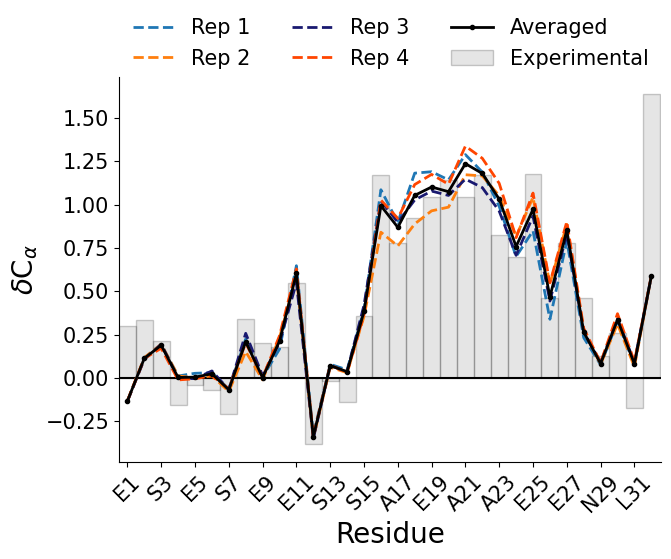

In [76]:
fig,axs = plt.subplots(1,1,figsize=(7,5))

axs.axhline(0,c='k')


axs.plot(range(32), rep_CS[0][0,1000:].mean(axis=0), ls='--', lw=2, color='tab:blue',     label='Rep 1')
axs.plot(range(32), rep_CS[1][0,1000:].mean(axis=0), ls='--', lw=2, color='tab:orange',   label='Rep 2')
axs.plot(range(32), rep_CS[2][0,1000:].mean(axis=0), ls='--', lw=2, color='midnightblue', label='Rep 3')
axs.plot(range(32), rep_CS[3][0,1000:].mean(axis=0), ls='--', lw=2, color='orangered',    label='Rep 4')
axs.bar(range(32), experimental_CS[0] - random_coil_CS[0], width=1, alpha=0.2, ec='k', color='grey', label='Experimental')
axs.plot(range(32), np.mean([rep_CS[0][0,1000:].mean(axis=0),rep_CS[1][0,1000:].mean(axis=0),rep_CS[2][0,1000:].mean(axis=0),rep_CS[3][0,1000:].mean(axis=0)], axis=0), c='k', marker='.', lw=2, label='Averaged')

axs.legend(frameon=False, fontsize=15, ncols=3, loc=[0.01,1])

axs.spines[['top','right']].set_visible(False)
step = 2
axs.set_xticks(range(0,32,step),labels=[f"{MDA.lib.util.convert_aa_code(r.resname)}{r.resid}" for r in u.residues[::step]], rotation=45)
axs.set_xlim(-0.5,31.6)

axs.set_ylabel(r'$\delta$C$_\alpha$', fontsize=20)
axs.set_xlabel('Residue', fontsize=20)
axs.tick_params('both',labelsize=15)

fig.savefig(f"CCPN_repavg_2.png", dpi=300, bbox_inches='tight')

plt.show()


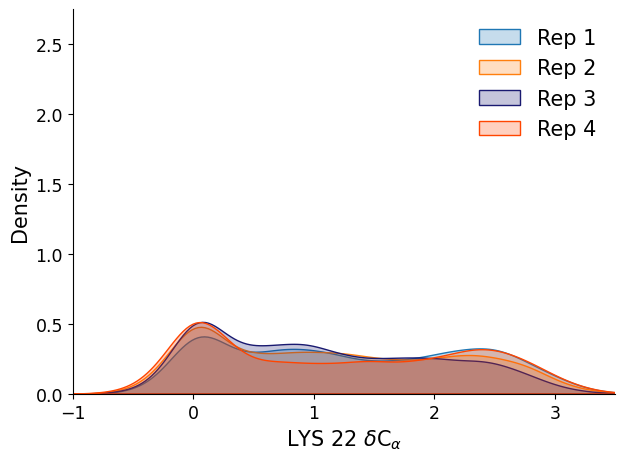

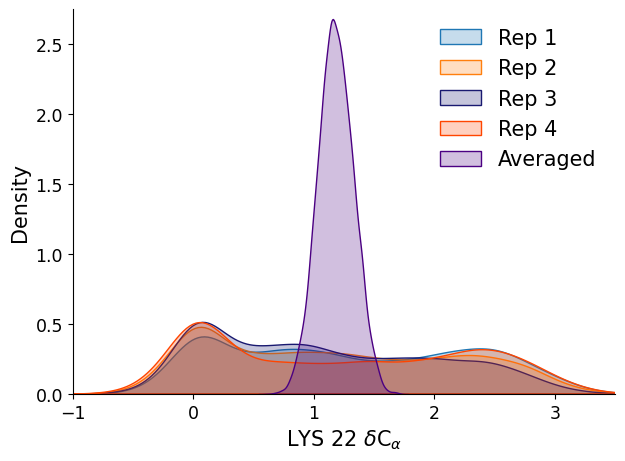

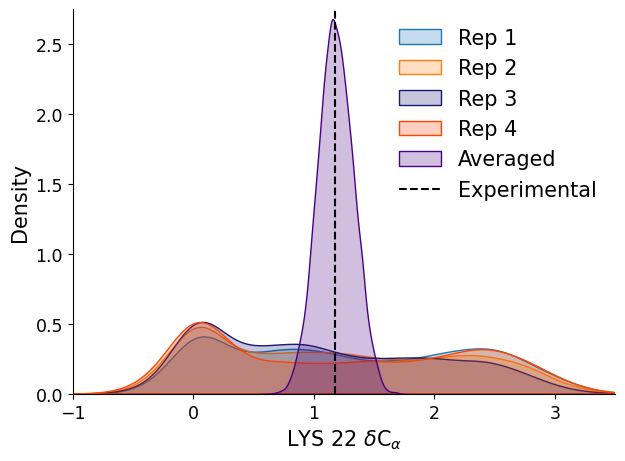

In [ ]:
import seaborn as sns
r = 21
step = 1

fig,axs = plt.subplots(1,1,figsize=(7,5))
sns.kdeplot(rep_CS[0][0,:M:step,r], fill=True, label='Rep 1', color='tab:blue')
sns.kdeplot(rep_CS[1][0,:M:step,r], fill=True, label='Rep 2', color='tab:orange')
sns.kdeplot(rep_CS[2][0,:M:step,r], fill=True, label='Rep 3', color='midnightblue')
sns.kdeplot(rep_CS[3][0,:M:step,r], fill=True, label='Rep 4', color='orangered')
#sns.kdeplot(np.mean([rep_CS[0][0,:M:step,r], rep_CS[1][0,:M:step,r], rep_CS[2][0,:M:step,r], rep_CS[3][0,:M:step,r]], axis=0), color='indigo', fill=True, label='Averaged')
#axs.axvline(experimental_CS[0,r]-random_coil_CS[0,r], c='k', ls='--', label='Experimental')
axs.legend(frameon=False, fontsize=15)
axs.spines[['top','right']].set_visible(False)
axs.set_xlim([-1,3.5])
axs.set_ylim([0,2.75])
axs.set_xticks([-1,0,1,2,3])
axs.tick_params('both', labelsize=12.5)
axs.set_ylabel('Density', fontsize=15)
this_r = u.residues[r]
axs.set_xlabel(f"{this_r.resname} {this_r.resid} "+r"$\delta$C$_\alpha$", fontsize=15)
fig.savefig(f"dCA_dists_0.png", dpi=300, bbox_inches='tight')

fig,axs = plt.subplots(1,1,figsize=(7,5))
sns.kdeplot(rep_CS[0][0,:M:step,r], fill=True, label='Rep 1', color='tab:blue')
sns.kdeplot(rep_CS[1][0,:M:step,r], fill=True, label='Rep 2', color='tab:orange')
sns.kdeplot(rep_CS[2][0,:M:step,r], fill=True, label='Rep 3', color='midnightblue')
sns.kdeplot(rep_CS[3][0,:M:step,r], fill=True, label='Rep 4', color='orangered')
sns.kdeplot(np.mean([rep_CS[0][0,:M:step,r], rep_CS[1][0,:M:step,r], rep_CS[2][0,:M:step,r], rep_CS[3][0,:M:step,r]], axis=0), color='indigo', fill=True, label='Averaged')
#axs.axvline(experimental_CS[0,r]-random_coil_CS[0,r], c='k', ls='--', label='Experimental')
axs.legend(frameon=False, fontsize=15)
axs.spines[['top','right']].set_visible(False)
axs.set_xlim([-1,3.5])
axs.set_ylim([0,2.75])
axs.set_xticks([-1,0,1,2,3])
axs.tick_params('both', labelsize=12.5)
axs.set_ylabel('Density', fontsize=15)
this_r = u.residues[r]
axs.set_xlabel(f"{this_r.resname} {this_r.resid} "+r"$\delta$C$_\alpha$", fontsize=15)
fig.savefig(f"dCA_dists_1.png", dpi=300, bbox_inches='tight')

fig,axs = plt.subplots(1,1,figsize=(7,5))
sns.kdeplot(rep_CS[0][0,:M:step,r], fill=True, label='Rep 1', color='tab:blue')
sns.kdeplot(rep_CS[1][0,:M:step,r], fill=True, label='Rep 2', color='tab:orange')
sns.kdeplot(rep_CS[2][0,:M:step,r], fill=True, label='Rep 3', color='midnightblue')
sns.kdeplot(rep_CS[3][0,:M:step,r], fill=True, label='Rep 4', color='orangered')
sns.kdeplot(np.mean([rep_CS[0][0,:M:step,r], rep_CS[1][0,:M:step,r], rep_CS[2][0,:M:step,r], rep_CS[3][0,:M:step,r]], axis=0), color='indigo', fill=True, label='Averaged')
axs.axvline(experimental_CS[0,r]-random_coil_CS[0,r], c='k', ls='--', label='Experimental')
axs.legend(frameon=False, fontsize=15)
axs.spines[['top','right']].set_visible(False)
axs.set_xlim([-1,3.5])
axs.set_ylim([0,2.75])
axs.set_xticks([-1,0,1,2,3])
axs.tick_params('both', labelsize=12.5)
axs.set_ylabel('Density', fontsize=15)
this_r = u.residues[r]
axs.set_xlabel(f"{this_r.resname} {this_r.resid} "+r"$\delta$C$_\alpha$", fontsize=15)
fig.savefig(f"dCA_dists_2.png", dpi=300, bbox_inches='tight')

In [7]:
M = max([rep_CS[i].shape[1] for i in range(4)])

In [ ]:
print("loading modules")
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
print("loaded")

def get_FE(x,y, xmin,xmax,ymin,ymax, nbins=300):
    X, Y = np.mgrid[xmin:xmax:300j, ymin:ymax:300j] 

    positions = np.vstack([X.ravel(), Y.ravel()])
    values = np.vstack([x, y])                    

    kernel = gaussian_kde(values)  
    kernel.set_bandwidth(bw_method=kernel.factor*0.5)
    Z = np.reshape(kernel(positions).T, X.shape) 

    FE = -np.log(Z)  
    FE = FE - np.min(FE) 

    return X,Y,FE

def plot_FES(X,Y,xmin,xmax,ymin,ymax,FE,FE_max,ax, orig_cmap=plt.cm.coolwarm, difference=False, cntr_steps=0.5):

    min_val, max_val = 0.1, 1.0 
    n = 10 
    colors = orig_cmap(np.linspace(min_val, max_val, n)) 
    #colors = colors[::-1]  
    cmap = mpl.colors.LinearSegmentedColormap.from_list("mycmap", colors)

    levels = np.arange(-FE_max, FE_max, cntr_steps)  if difference else np.arange(0, FE_max, cntr_steps)  
    FE[np.abs(FE)>FE_max] = np.nan
    cs = ax.contourf(X, Y, FE, cmap=cmap,  extend='max', levels=levels, extent=[xmin, xmax, ymin, ymax], alpha=1)
    #cs = ax.imshow(FE, cmap=cmap, vmin=levels[0],vmax=levels[-1])
    ax.contour(X, Y, FE, colors='k', extend='max', levels=levels, extent=[xmin, xmax, ymin, ymax], linewidths=1,alpha=0.5)
    
    ax.set_xlim((np.min((xmin,ymin)), np.max((xmax,ymax))))  
    ax.set_ylim((np.min((xmin,ymin)), np.max((xmax,ymax))))  

    ax.autoscale(False)

    ax.set_axis_off()
    ax.set_aspect('equal')

    return cs
print("loading")
arr = np.loadtxt("NapShift_Tests_For_Jack/TestSystems/FCP1/ForceFields/Martini3/simulations/ens_avg/exp_CS/4reps/elvim.dat")
print("loaded")
x =   arr[::1,0]
y =   arr[::1,1]

xmin = x.min() - 0.01
xmax = x.max() + 0.01
ymin = y.min() - 0.01
ymax = y.max() + 0.01


X,Y, FE = get_FE(x,y,x.min(),x.max(),y.min(),y.max())



loading modules
loaded
loading
loaded


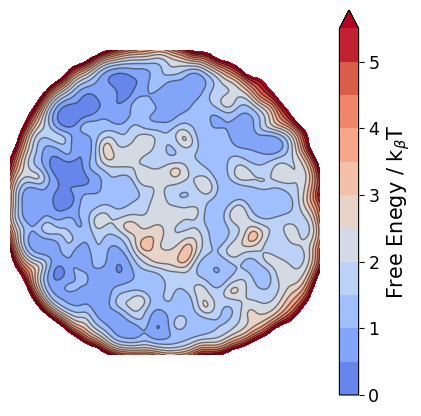

In [19]:
fig,axs = plt.subplots(1,1, figsize=(5,5), sharex=True, sharey=True)
orig_cmap=plt.cm.coolwarm
cntr_steps=0.5
FE_max = 6

min_val, max_val = 0.1, 1.0 
n = 10 
colors = orig_cmap(np.linspace(min_val, max_val, n)) 
#colors = colors[::-1]  
cmap = mpl.colors.LinearSegmentedColormap.from_list("mycmap", colors)
levels = np.arange(0, FE_max, cntr_steps)  
FE[np.abs(FE)>FE_max] = np.nan
cs = axs.contourf(X, Y, FE, cmap=cmap,  extend='max', levels=levels, extent=[xmin, xmax, ymin, ymax], alpha=1)
axs.contour(X, Y, FE, colors='k', extend='max', levels=levels, extent=[xmin, xmax, ymin, ymax], linewidths=1,alpha=0.5)
#axs.set_xlim((np.min((xmin,ymin)), np.max((xmax,ymax))))  
#axs.set_ylim((np.min((xmin,ymin)), np.max((xmax,ymax))))  
axs.autoscale(False)

cbar = fig.colorbar(cs)
cbar.ax.set_ylabel(r"Free Enegy / k$_\beta$T", fontsize=15)
cbar.ax.tick_params('both', labelsize=12.5)
axs.set_axis_off()
axs.set_aspect('equal')
fig.savefig('FES.png', dpi=300, bbox_inches='tight')

/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


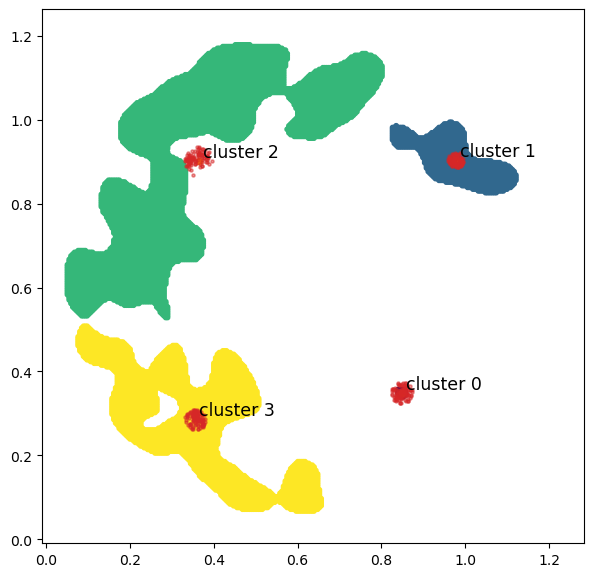

/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


In [20]:
from sklearn.neighbors import KDTree
from sklearn.cluster import HDBSCAN
import MDAnalysis as MDA

def plot_clusters(FE, X,Y, x,y, xmin,xmax, ymin,ymax, thresh):
    xs = X.diagonal().flatten()[np.argwhere(FE<thresh)[:,0]]
    ys = Y.diagonal().flatten()[np.argwhere(FE<thresh)[:,1]]


    #kmeans = KMeans(n_clusters=K, random_state=0).fit(np.array([xs,ys]).T)
    #clusters = kmeans.predict(np.array([xs,ys]).T)
    #centers = kmeans.cluster_centers_
    clustering = HDBSCAN(store_centers='centroid').fit(np.array([xs,ys]).T)
    clusters = clustering.labels_
    centers = clustering.centroids_

    tree = KDTree(np.array([x,y]).T, leaf_size=2)
    dist, ind = tree.query(centers, k=100)

    fig,axs = plt.subplots(1,1,figsize=(7,7))
    axs.scatter(xs, ys, s=10, c=clusters)
    axs.scatter(centers[:,0], centers[:,1], s=20, c='tab:orange')
    axs.scatter(x[ind[:,:]],y[ind[:,:]], s=5, c='tab:red', alpha=0.5)
    axs.set_xlim([xmin,xmax])
    axs.set_ylim([ymin,ymax])
    axs.set_aspect('equal')
    for cluster_idx in range(centers.shape[0]):
        axs.text(centers[cluster_idx][0]+0.01, centers[cluster_idx][1]+0.01, f"cluster {cluster_idx}", fontsize=12.5)

    
    plt.show()
    return ind

from MDAnalysis.analysis import align
import mdtraj as md
def write_cluster_traj(pdbfile, xtcfile, outdir, outname, ind, offset, align_sel='name CA'):
    traj = md.load_xtc(xtcfile, top=pdbfile)
    for cluster_idx in range(ind.shape[0]):
        with md.formats.XTCTrajectoryFile(f"{outdir}/{outname}_cluster_{cluster_idx}.xtc", 'w') as f:
            for frame in ind[cluster_idx]:
                f.write(traj[frame+offset].xyz)

        align_select = align_sel

        u_ref = MDA.Universe(pdbfile)
        u = MDA.Universe(pdbfile, f"{outdir}/{outname}_cluster_{cluster_idx}.xtc")

        align.AlignTraj(u,  # trajectory to align
                u_ref,  # reference
                select=align_select,  # selection of atoms to align
                filename=f"{outdir}/{outname}_cluster_{cluster_idx}_aligned.xtc",  # file to write the trajectory to
                match_atoms=True,  # whether to match atoms based on mass
               ).run()

ind = plot_clusters(FE, X,Y, x,y, xmin,xmax, ymin,ymax, 1)
write_cluster_traj("NapShift_Tests_For_Jack/TestSystems/FCP1/ForceFields/Martini3/system_helical/helical_modelled_cg.pdb", 
                   "NapShift_Tests_For_Jack/TestSystems/FCP1/ForceFields/Martini3/simulations/ens_avg/exp_CS/4reps/combined.xtc",
                   "NapShift_Tests_For_Jack/TestSystems/FCP1/ForceFields/Martini3/simulations/ens_avg/exp_CS/4reps/",
                   "ensavg_thresh_1",
                   ind,
                   offset=0,
                   align_sel="name BB")